# debanding

> Investigating and removing banding artefacts from a set of observations.


In [ ]:
# | default_exp euclid.debanding

In [ ]:
# | export

import warnings

import numpy as np
import xarray as xr

from nicl.euclid.xarray import xr_fast_mask
from nicl.filter import sampled_median_filter

In [ ]:
# | hide
# Additional imports used in the examples

import matplotlib.pyplot as plt
import astropy.io.fits as fits

from nicl.euclid.utilities import default_data_path
from nicl.euclid.xarray import read_all_zarr_refs

For now we perform this work on the original L2 data. However, it would probably be best to do this step after the atemporal background subtraction, and possibly after persistence removal.

In [ ]:
path = default_data_path("Q1_R1", "NIR")
zarr_path = default_data_path("zarr", "Q1_R1", "NIR")
outpath = default_data_path("Q1_R1_processed_test", "debanding")

To measure the banding we mask objects in the data, apply a filter to remove large scale variations, and then take the median of the data in the x and y directions.

In [ ]:
ds, wcs, zp = read_all_zarr_refs(zarr_path)

In [ ]:
# | exporti

def filter_and_mask_data(data, scale=200):
    """Filter the data to remove large scale variations.
    
    A smoothed, median filtered, version of the data is subtracted from the original data.
    The result is is then masked using an object mask created from the original data.
    The result should a map of the small scale variations in the background.
    """
    # this currently doesn't work, apparently because of a bug in kerchunk, interpreting the type incorrectly (unsigned int32?)
    # invalid = original_data["DQ"]
    # invalid = invalid > 0
    # mask = mask | invalid
    # data = data.where(~mask)
    smoothed = sampled_median_filter(data, scale, dims=["y", "x"])
    filtered_data = data - smoothed
    mask_params = {
        "nsigma": 2.0,
        "erosion_iterations": 1,
        "dilation_radius": 2.0,
        "dilation_iterations": 2,
    }
    mask = xr_fast_mask(data, mask_params=mask_params, estimate_background=True)
    filtered_data = filtered_data.where(~mask)
    return filtered_data

In [ ]:
data = ds["SCI"].sel(filter="J", observation_id=2683, dither=[0, 1])

In [ ]:
data = data.persist()

In [ ]:
filtered_data = filter_and_mask_data(data).persist()

In [ ]:
med_x = filtered_data.median("x")
med_x -= med_x.median("y")
med_y = filtered_data.median("y")
med_y -= med_y.median("x")

## Examples

Let's examine the banding for an example observation.

In [ ]:
def plot_banding(med, dim, filter, obs_id, just_one=False):
    d0 = med.sel(dither=0)
    d0med = d0.median(dim)
    d1 = med.sel(dither=1)
    d1med = d1.median(dim)
    if just_one:
        fig, ax = plt.subplots(figsize=(6, 3))
    else:
        fig, ax = plt.subplots(figsize=(6, 6))
    if just_one:
        ax.plot(d0.T[:,0], ".", markersize=1)
    else:
        ax.plot(d0.T + np.arange(16) * 40, ".", markersize=1)
    ax.axes.set_prop_cycle(None)
    if just_one:
        ax.plot(d1.T[:,0] + 15, ".", markersize=1)
    else:
        ax.plot(d1.T + np.arange(16) * 40 + 15, ".", markersize=1)
    for i, m in enumerate(d0med.values + np.arange(16) * 40):
        ax.axhline(m, alpha=0.25, color="k")
        det = d0.detector.values[i]
        if not just_one:
            ax.text(-1, m, det, va="bottom", ha="right", fontsize=10, color="k")
        if just_one:
            break
    for m in d1med.values + np.arange(16) * 40 + 15:
        ax.axhline(m, alpha=0.25, color="k")
        if just_one:
            break
    ax.set_xlabel(dim)
    ax.set_yticks([])
    ax.set_ylabel("median flux")
    ax.set_xlim(xmin=-150)
    plt.tight_layout()
    outpath.mkdir(parents=True, exist_ok=True)
    plt.savefig(outpath / f"banding_{dim}_{filter}_{obs_id}.pdf")

The following plots show the median flux across one axis as a function of the other axis. A pair of lines is shown for each detector (labelled on the left). Within each pair, the two lines show the behaviour for two different dithers. An arbitrary offset has been added to the y-axis.


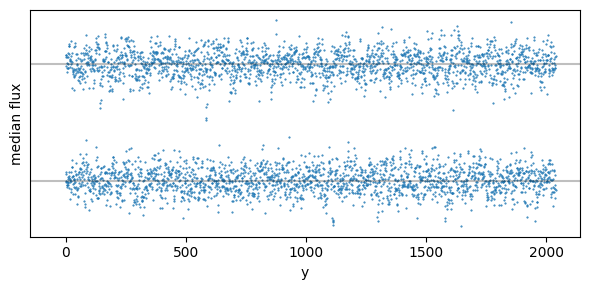

In [ ]:
plot_banding(med_x, "y", "J", 2683, just_one=True)

There are some variations in the median flux as we move along the y-axis, which appear as horizontal stripes in the images. These typically have relatively smooth edges. The features do not persist across dithers.

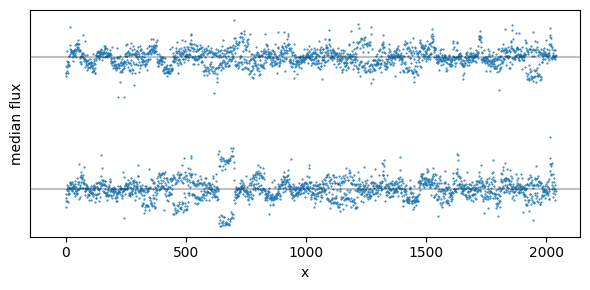

In [ ]:
plot_banding(med_y, "x", "J", 2683, just_one=True)

There are some variations in the median flux as we move along the x-axis, which appear as vertical stripes in the images. However, there are distinctive 'bifurcations' in bands ~50 pixels wide. In these bands the median flux oscillates between neighbouring columns. While some of these features persist across dithers, others do not, suggesting they come and go on the timescale of several minutes.

## Correction

We can correct the banding by subtracting the median flux in the x and y directions.


In [ ]:
# | export


def banding_correction(data, rows=True, cols=True, max_size=200):
    if isinstance(data, np.ndarray):
        data = xr.DataArray(data, dims=["y", "x"])
        return_numpy = True
    else:
        return_numpy = False
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", "invalid value encountered in reduce")
        filtered_data = filter_and_mask_data(data, scale=max_size)
        
        if rows:
            med_x = filtered_data.median("x")
            try:
                med_med_x = med_x.median("y")
            except NotImplementedError:
                med_med_x = med_x.as_numpy().median("y")
            med_x -= med_med_x
        if cols:
            med_y = filtered_data.median("y")
            try:
                med_med_y = med_y.median("x")
            except NotImplementedError:
                med_med_y = med_y.as_numpy().median("x")
            med_y -= med_med_y
    correction = med_x + med_y
    try:
        med_correction = correction.median()
    except NotImplementedError:
        med_correction = correction.as_numpy().median()
    correction -= med_correction
    if return_numpy:
        correction = correction.to_numpy()
    return correction

In [ ]:
zoom_limits = ((510, 810), (300, 600))


def plot_zoom_box(ax, i):
    ax[0, i].plot(
        [
            zoom_limits[0][0],
            zoom_limits[0][1],
            zoom_limits[0][1],
            zoom_limits[0][0],
            zoom_limits[0][0],
        ],
        [
            zoom_limits[1][0],
            zoom_limits[1][0],
            zoom_limits[1][1],
            zoom_limits[1][1],
            zoom_limits[1][0],
        ],
        "k-",
    )


def no_ticks(ax):
    ax.set_xticks([])
    ax.set_yticks([])


def plot_dither(ax, i, img, vmin, vmax, cmap, interpolation):
    aximg = ax[0, i].imshow(
        img,
        vmin=vmin,
        vmax=vmax,
        origin="lower",
        cmap=cmap,
        interpolation=interpolation,
    )
    plot_zoom_box(ax, i)
    ax[1, i].imshow(
        img[
            zoom_limits[1][0] : zoom_limits[1][1], zoom_limits[0][0] : zoom_limits[0][1]
        ],
        vmin=vmin,
        vmax=vmax,
        origin="lower",
        cmap=cmap,
        interpolation=interpolation,
    )
    no_ticks(ax[0, i])
    no_ticks(ax[1, i])
    return aximg


def plot_example(
    example_data, corrected_data, vmin=60, vmax=90, cmap=None, interpolation=None
):
    fig, ax = plt.subplots(2, 3, figsize=(12, 12), width_ratios=(1, 1, 0.05))
    aximg = plot_dither(
        ax,
        0,
        example_data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        interpolation=interpolation,
    )
    plot_dither(
        ax,
        1,
        corrected_data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        interpolation=interpolation,
    )
    plt.colorbar(aximg, cax=ax[0, -1])
    ax[1, -1].set_visible(False)
    plt.tight_layout()
    plt.savefig(outpath / "example.pdf")

Here we show an example. Note that in the pipeline the debanding is done _after_ the persistence correction.

In [ ]:
example_data = ds["SCI"].sel(
    # Original example:
    filter="J", observation_id=2683, dither=0, detector="DET11"
    # Example containing large cluster:
    # filter="J", observation_id=2712, dither=2, detector="DET23"
)

In [ ]:
example_data = ds["SCI"].sel(
)


In [ ]:
example_data = example_data.persist()

In [ ]:
example_filtered_data = filter_and_mask_data(example_data, scale=200).as_numpy()

In [ ]:
plot_example(example_data - 75, example_filtered_data, vmin=-15, vmax=15)

In [ ]:
correction = banding_correction(example_data).persist()

In [ ]:
plot_example(example_data - 75, correction, vmin=-15, vmax=15)

In [ ]:
correction.as_numpy().median()

In [ ]:
corrected_data = example_data - correction
corrected_filtered_data = example_filtered_data - correction
corrected_filtered_data = corrected_filtered_data.where(~correction.isnull())

In [ ]:
outpath.mkdir(parents=True, exist_ok=True)
fits.writeto(outpath / "corrected_data.fits", corrected_data.to_numpy(), overwrite=True)
fits.writeto(
    outpath / "corrected_filtered_data.fits",
    corrected_filtered_data.to_numpy(),
    overwrite=True,
)
fits.writeto(outpath / "data.fits", example_data.to_numpy(), overwrite=True)
fits.writeto(
    outpath / "filtered_data.fits", example_filtered_data.to_numpy(), overwrite=True
)

In [ ]:
plot_example(example_data, corrected_data)

In [ ]:
plot_example(example_data - 75, corrected_filtered_data, vmin=-15, vmax=15)